In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset

In [2]:
url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
data = pd.read_csv(url)

In [3]:
data.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


### Preparing the dataset
Use only the following columns:

In [4]:
required_col = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']

df = data[required_col]

In [5]:
df.head(2)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3


### EDA

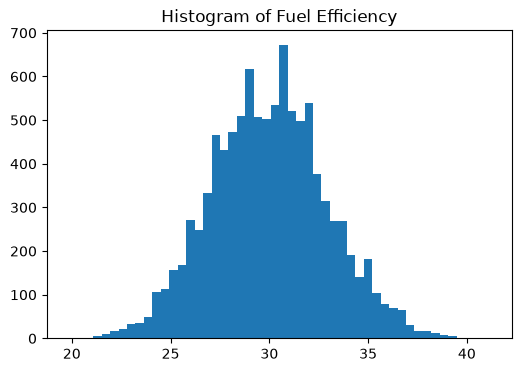

In [6]:
plt.figure(figsize = (6,4))
plt.hist(df.fuel_efficiency_mpg, bins = 50)
plt.title("Histogram of Fuel Efficiency")
plt.show()

 Does it have a long tail?  No, it does not

### Question 1: There's one column with missing values. What is it?

'engine_displacement'
'horsepower'
'vehicle_weight'
'model_year'

In [7]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

horssepower is the column with Missing Value

### Question 2 What's the median (50% percentile) for variable 'horsepower'?

204
254
304
354

In [8]:
df.horsepower.median()

np.float64(254.0)

### Prepare and split the dataset
Shuffle the filtered dataset and create the split exactly as in the lecture:

In [9]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [10]:
df_train.isna().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [11]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [12]:
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

In [13]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [14]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001


In [15]:
len(y_train), len(y_val), len(y_test)

(6000, 2000, 2000)

### Linear Regression and RMSE Function

In [16]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

### Question 3

filling missing value with 0 and mean of the variable and compare the one with better result on linear regression

In [17]:
## training models
X_train_zero = df_train.fillna(0).values   #the fillna are named X_train_zero
X_mean = df_train.mean()
X_train_mean = df_train.fillna(X_mean).values  #fill with mean are named X_train_mean
w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)


In [18]:

## prediction
X_val_zero = df_val.fillna(0).values   #the fillna are named X_val_zero
X_mean = df_val.mean()
X_val_mean = df_val.fillna(X_mean).values  #fill with mean are named X_val_mean

y_pred_zero = w0_zero + X_val_zero.dot(w_zero)
rmse_zero = round(rmse(y_val, y_pred_zero),3)

y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
rmse_mean = round(rmse(y_val, y_pred_mean), 3)

print(f"When fillna with Zero RMSE = {rmse_zero}")
print(f"When fillna with Mean RMSE = {rmse_mean}")

When fillna with Zero RMSE = 2.205
When fillna with Mean RMSE = 2.202


Which option gives better RMSE? when fill with Mean value is better than Zero 

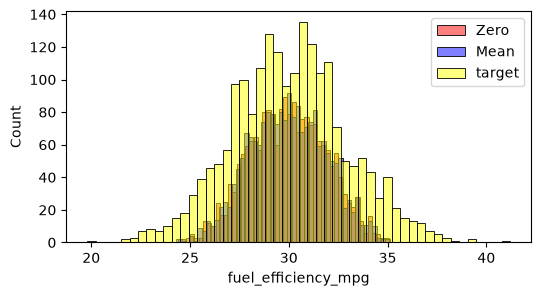

In [19]:
plt.figure(figsize = (6,3))
sns.histplot(y_pred_zero, color='red', label='Zero', alpha=0.5, bins=50)
sns.histplot(y_pred_mean, color='blue',label='Mean', alpha=0.5, bins=50)
sns.histplot(y_val, color='yellow', label='target', alpha=0.5, bins=50)
plt.legend()
plt.show()

### Question 4 : let's train a regularized linear regression.

In [20]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]
    

In [21]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train_zero, y_train, r=r)

    
    y_pred = w0 + X_val_zero.dot(w)
    score = round(rmse(y_val, y_pred),4)
    
    print(f"r = {r},--> w0 = {round(w0,4)}, --> rmse = {score}")

r = 0,--> w0 = -153.885, --> rmse = 2.2053
r = 0.01,--> w0 = -148.3092, --> rmse = 2.2058
r = 0.1,--> w0 = -111.8387, --> rmse = 2.2241
r = 1,--> w0 = -32.3319, --> rmse = 2.3492
r = 5,--> w0 = -7.7729, --> rmse = 2.4094
r = 10,--> w0 = -3.9871, --> rmse = 2.4195
r = 100,--> w0 = -0.4082, --> rmse = 2.4292


Which r gives the best RMSE?  r = 0 is better

### Question 5:  Let's find out how selecting the seed influences our score.
Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].

In [22]:
def split_train(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    np.random.seed(seed)
    
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg']
    y_val = df_val['fuel_efficiency_mpg']
    y_test = df_test['fuel_efficiency_mpg']

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # Training
    X_train = df_train.fillna(0).values
    w0, w = train_linear_regression(X_train, y_train)

    # Prediction
    X_val = df_val.fillna(0).values
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)

    return score

In [23]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    score = split_train(df, seed)
    scores.append(score)

std = np.std(scores)

round(std, 3)

np.float64(0.029)

### Question 6: Combining train and validation datasets.
Fill the missing values with 0 and train a model with r=0.001.
What's the RMSE on the test dataset?

In [24]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

#separate y
y_full_train = df_full_train['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

del df_full_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

#Fill missing values with 0:
X_full_train = df_full_train.fillna(0).values
X_test = df_test.fillna(0).values

#train with reg = 0.001
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [25]:
#prediction
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

round(score, 3)

np.float64(2.236)